In [7]:
from src import *
from myutils import *

In [155]:
freq_list = np.linspace(0.1, 0.4, 601)
A = 5 * DMD.PIXEL_SIZE/2
sampling_rate = 20

pic_time = (1 / (sampling_rate * freq_list) / 2 * 1e6).astype(int)

# DMD 可能会有一个小延迟, 也有一定的误差
real_freq_list = 1 / ((pic_time) * 2) * 1e6 / sampling_rate

np.random.normal(6e-3, 8e-4) 可能差不多, 还有 (6e-3, 280e-6)

pic_time 可能有一个 10 us 左右的误差

In [160]:
@parallelize()
def main(f):
    cropped, noise = [], []
    for _ in range(200):
        meta = MetaData('SPADE', f, A, 0)
        sim = Simulator(meta, delay=np.random.normal(6e-3, 10e-6), waveform='sign')
        cropped_, noise_ = sim.gen()
        cropped.append(cropped_)
        noise.append(noise_)
    c = Estimates(np.array(cropped), meta, noise=np.array(noise).mean(-1))
    return Estimation.FromEstimates(c)

In [161]:
cs = main(real_freq_list)

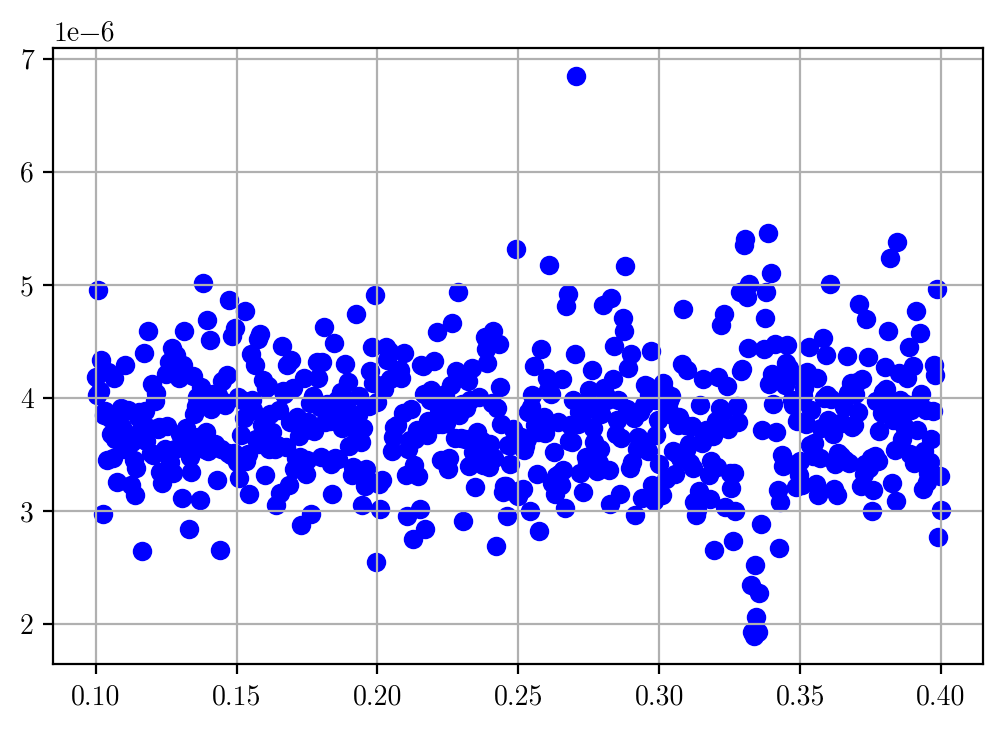

In [162]:
x = [cs[i].metadata.ground_truth for i in range(601)]
y = [cs[i].frequency_estimates.var() * cs[i].photons.mean() for i in range(601)]

scatter(freq_list, y)
# plt.ylim(0, 5e-5)

In [2]:
# @cache
# @parallelize()
# def main(freq, repeat=200):
#     meta = MetaData('DI', freq, 5*DMD.PIXEL_SIZE/2, 0)
#     c = Simulator(meta)
#     cropped_data = np.array([c.gen(400) for _ in range(repeat)])
#     td = td_estimator(meta.measurement, cropped_data)
#     f_est = np.array([freq_estimator(td_) for td_ in td])
#     return f_est


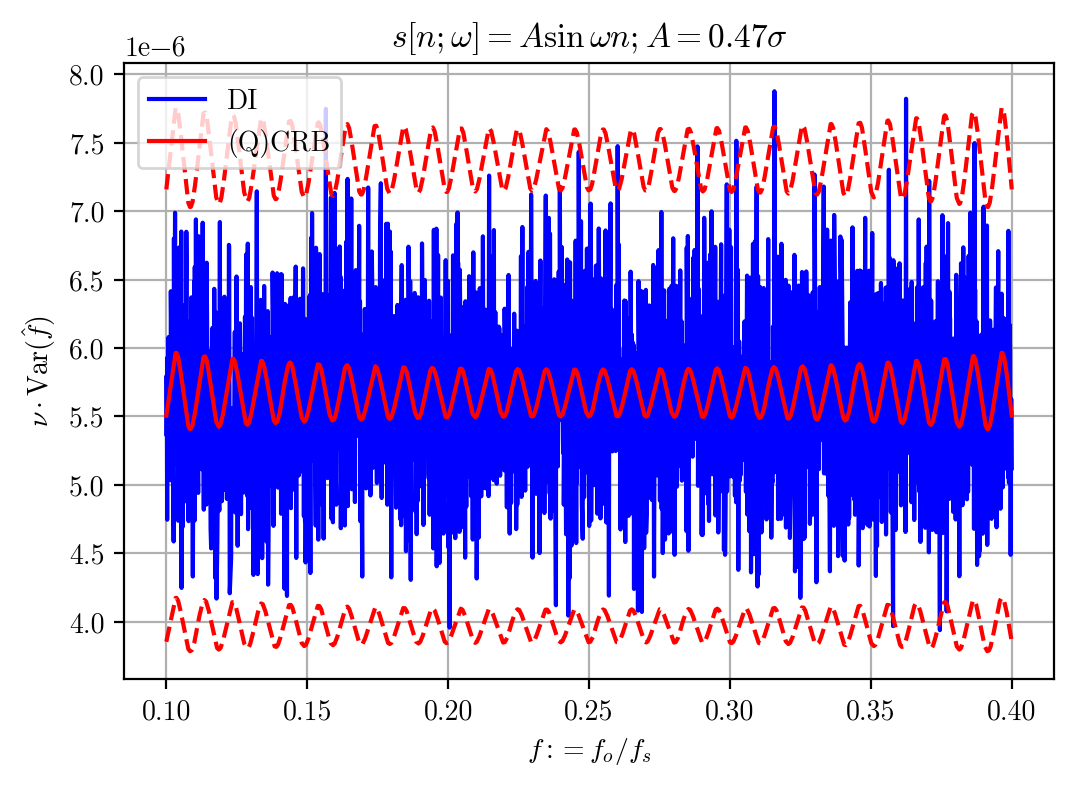

In [3]:
f_est = np.load(r'__simulations__\di_sin.npy')

plot(np.linspace(0.1, 0.4, 3000), f_est.var(-1) * 400, label='DI')

x_axis = np.linspace(0.1, 0.4, 1000)
crb = (1 / FisherInformation([5 * DMD.PIXEL_SIZE / 2], x_axis))[0]

plot(x_axis, crb, 'r-',title=r'$s[n;\omega] =A \sin\omega n; A= 0.47\sigma$', label='(Q)CRB')
plot(x_axis, 1.3 * crb, 'r--', ylabel=r'$\nu\cdot{\rm Var}(\hat f)$')
plot(x_axis, 0.7 * crb, 'r--', xlabel=r'$f:=f_o/f_s$')

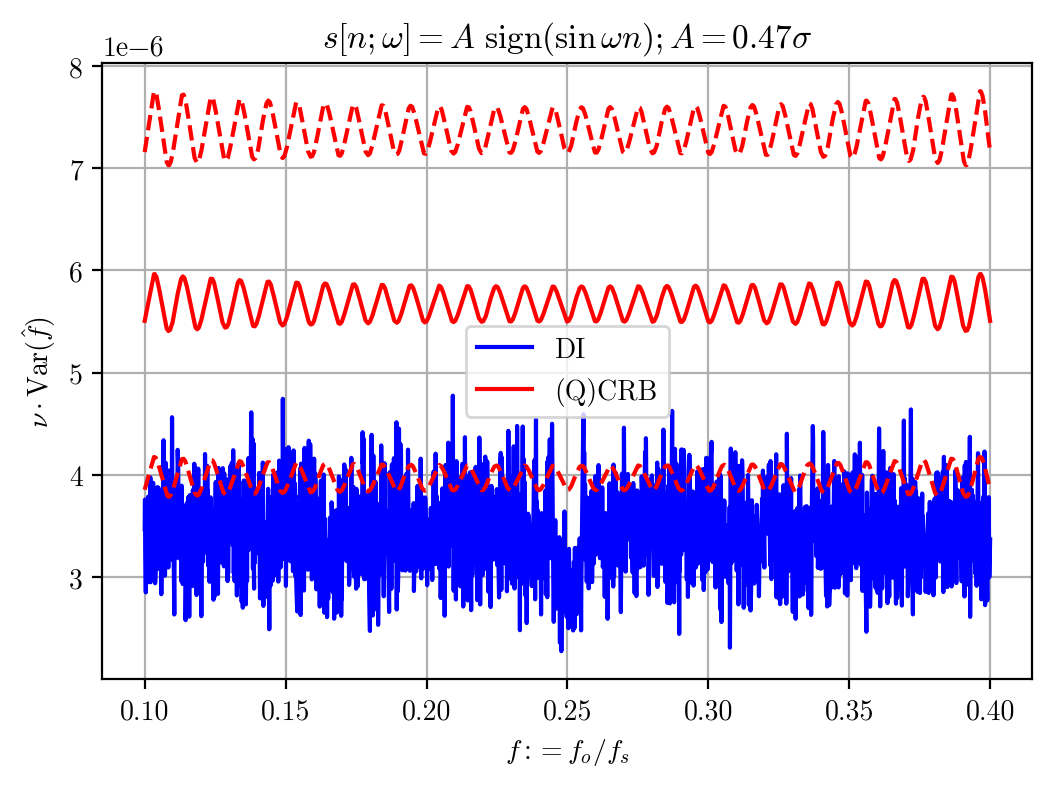

In [4]:
f_est = np.load(r'__simulations__\di_sign.npy')

plot(np.linspace(0.1, 0.4, 3000), f_est.var(-1) * 400, label='DI')

x_axis = np.linspace(0.1, 0.4, 1000)
crb = (1 / FisherInformation([5 * DMD.PIXEL_SIZE / 2], x_axis))[0]

plot(x_axis, crb, 'r-',title=r'$s[n;\omega] =A~{\rm sign}(\sin\omega n); A= 0.47\sigma$', label='(Q)CRB')
plot(x_axis, 1.3 * crb, 'r--', ylabel=r'$\nu\cdot{\rm Var}(\hat f)$')
plot(x_axis, 0.7 * crb, 'r--', xlabel=r'$f:=f_o/f_s$')

In [7]:
@cache
@parallelize()
def main(freq, repeat=200):
    meta = MetaData('SPADE', freq, 5*DMD.PIXEL_SIZE/2, 0, 20)
    c = Simulator(meta, 'sign')
    cropped_data = np.array([c.gen(60) for _ in range(repeat)])
    td = td_estimator(meta.measurement, cropped_data, spade_method='zhou2023')
    f_est = np.array([freq_estimator(td_) for td_ in td])
    return f_est


In [8]:
f_est = main(np.linspace(0.1, 0.4, 3000))

In [9]:
np.save('spade_sign_zhou2023.npy', f_est)

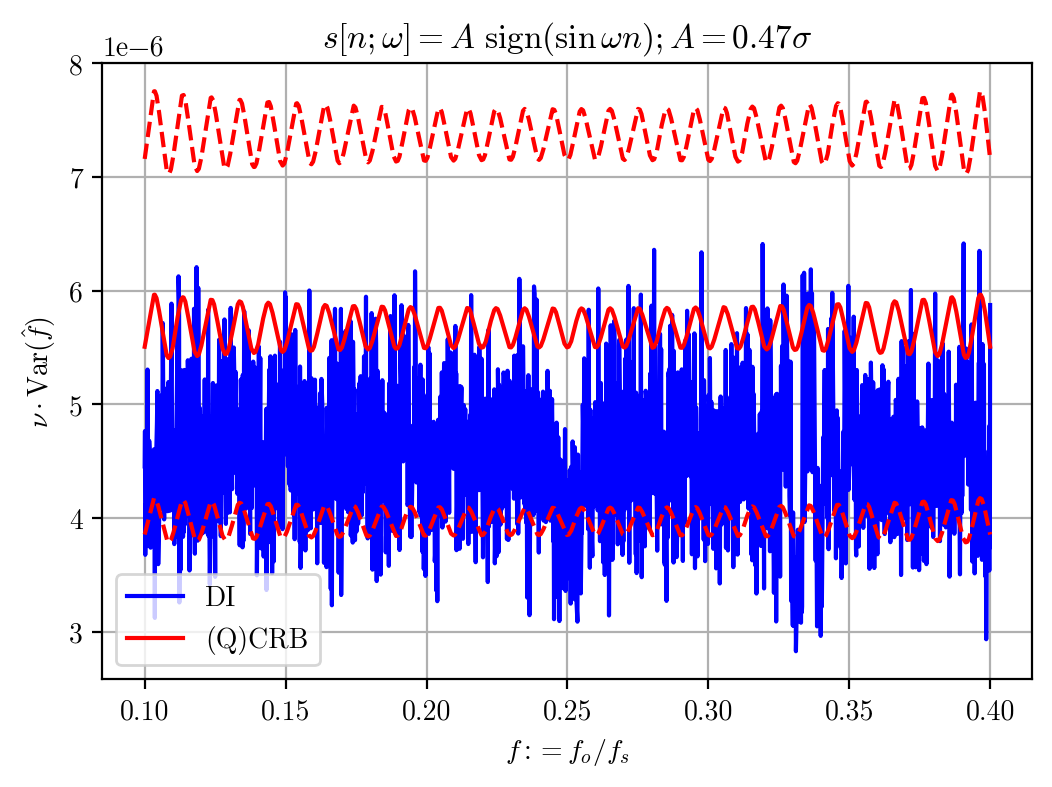

In [10]:
plot(np.linspace(0.1, 0.4, 3000), np.array(f_est).var(-1) * 60, label='DI')

x_axis = np.linspace(0.1, 0.4, 1000)
crb = (1 / FisherInformation([5 * DMD.PIXEL_SIZE / 2], x_axis))[0]

plot(x_axis, crb, 'r-',title=r'$s[n;\omega] =A~{\rm sign}(\sin\omega n); A= 0.47\sigma$', label='(Q)CRB')
plot(x_axis, 1.3 * crb, 'r--', ylabel=r'$\nu\cdot{\rm Var}(\hat f)$')
plot(x_axis, 0.7 * crb, 'r--', xlabel=r'$f:=f_o/f_s$')

In [2]:

meta = MetaData('SPADE', 0.01, 5*DMD.PIXEL_SIZE/2, 0, sampling_rate=1)
c = Simulator(meta)
cropped_data = np.array([c.gen(1000, sample_length=200) for _ in range(200)])

In [20]:
td = td_estimator('SPADE', cropped_data, spade_method='zhou2023')

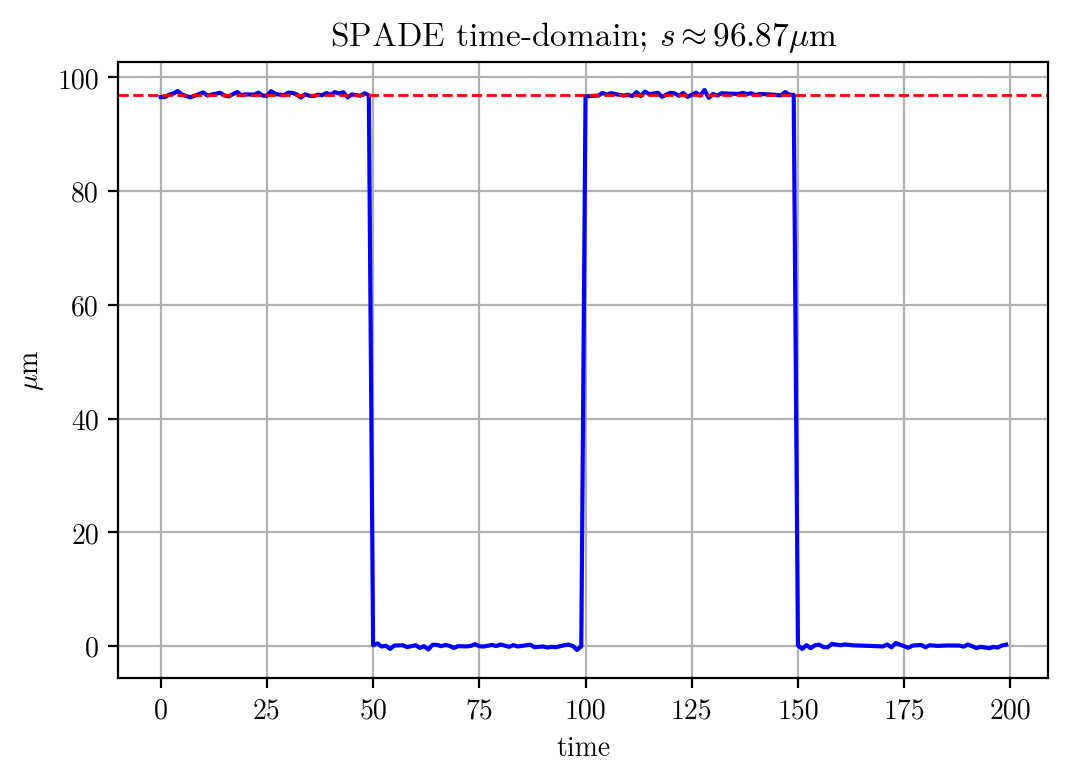

In [22]:
plot(td.mean(0), title=r'SPADE time-domain; $s\approx 96.87 {\rm \mu m}$', ylabel=r'${\rm \mu m}$', xlabel='time')
axline(h=5*DMD.PIXEL_SIZE,c='r', w=1)

$$
\frac{n1- n2}{ns} = \frac s\sigma exp(-s^2 / 4\sigma^2)
$$

$$
s\to 0; noise = 0
$$

$$
s = \sigma\frac{n1-n2}{n1+n2}
$$